# Data prep illustration


In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg

import numpy as np
from marvin.tools.cube import Cube

[WARNING]: /home/elom/.venv/phd/lib/python3.12/site-packages/brain/utils/general/general.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version

[INFO]: No release version set. Setting default to DR17
[WARNING]: /home/elom/.venv/phd/lib/python3.12/site-packages/marvin/__init__.py:400: MarvinUserWarning: path /home/elom/sas/dr17/manga/spectro/analysis/v3_1_1/3.1.0/dapall-v3_1_1-3.1.0.fits cannot be found. Setting dapall to None.
  warnings.warn('path {0} cannot be found. Setting dapall to None.'



# Custom functions

In [2]:
def spec_process(wave, flux, z):
    """
    Transform the observed spectrum to the rest-frame and normalize by median flux.
    """

    wave = wave / (1 + z)
    wave_mask = (wave > 3500) & (wave < 7500)
    wave = wave[wave_mask]
    # Shift to rest-frame
    flux = flux[wave_mask]
    
    return wave, flux

In [3]:
def add_thumbnail(
    ax, img, size="100%",
    bbox_to_anchor=(-0.06, 0.7, 0.3, 0.3)
):
    """
    Add a thumbnail image to the given axes.
    """
    ax_inset = inset_axes(
        ax, width=size, height=size,
        bbox_to_anchor=bbox_to_anchor,
        bbox_transform=ax.transAxes,  
    )

    ax_inset.imshow(img)
    ax_inset.axis('off')
    return ax_inset

# Directories

In [4]:
thesis_dir = "/home/elom/gdrive/career/portfolio/phd/thesis"
ch_3_dir = f"{thesis_dir}/chapters/03_figures/fiber_aperture"

# Plate-IFU: 7443-12703
https://magrathea.sdss.org/marvin/galaxy/7443-12703/

## Spectra

In [5]:
cube = Cube(plateifu='7443-12703')
# center
center_spaxel = cube[37, 37]
spec_center = center_spaxel.flux.value
wave_center = center_spaxel.flux.wavelength.value
wave_center_rest, spec_center = spec_process(wave_center, spec_center, z=0.0518)
# lower-left region
ll_spaxel = cube[23, 32]
spec_ll = ll_spaxel.flux.value
wave_ll = ll_spaxel.flux.wavelength.value
wave_ll_rest, spec_ll = spec_process(wave_ll, spec_ll, z=0.0518)

# upper-right region 
ur_spaxel = cube[52, 56]
spec_ur = ur_spaxel.flux.value
wave_ur = ur_spaxel.flux.wavelength.value
wave_ur_rest, spec_ur = spec_process(wave_ur, spec_ur, z=0.0518)
# upper-left region
ul_spaxel = cube[47, 33]
spec_ul = ul_spaxel.flux.value
wave_ul = ul_spaxel.flux.wavelength.value
wave_ul_rest, spec_ul = spec_process(wave_ul, spec_ul, z=0.0518)

## Photometry

In [6]:
# center region
center_image_name = 'fiber_apperture_manga_37_37.png'
center_img = mpimg.imread(f"{ch_3_dir}/{center_image_name}")
center_img = center_img[100:580, 10:-6, :]
# lower-left region
ll_image_name = 'fiber_apperture_manga_23_32.png'
ll_img = mpimg.imread(f"{ch_3_dir}/{ll_image_name}")
ll_img = ll_img[120:600, 150:630, :]
# upper-right region
ur_image_name = 'fiber_apperture_manga_52_56.png'
ur_img = mpimg.imread(f"{ch_3_dir}/{ur_image_name}")
ur_img = ur_img[60:540, 150:630, :]
# upper-left region
ul_image_name = 'fiber_apperture_manga_47_33.png'
ul_img = mpimg.imread(f"{ch_3_dir}/{ul_image_name}")
ul_img = ul_img[60:540, 55:535, :]

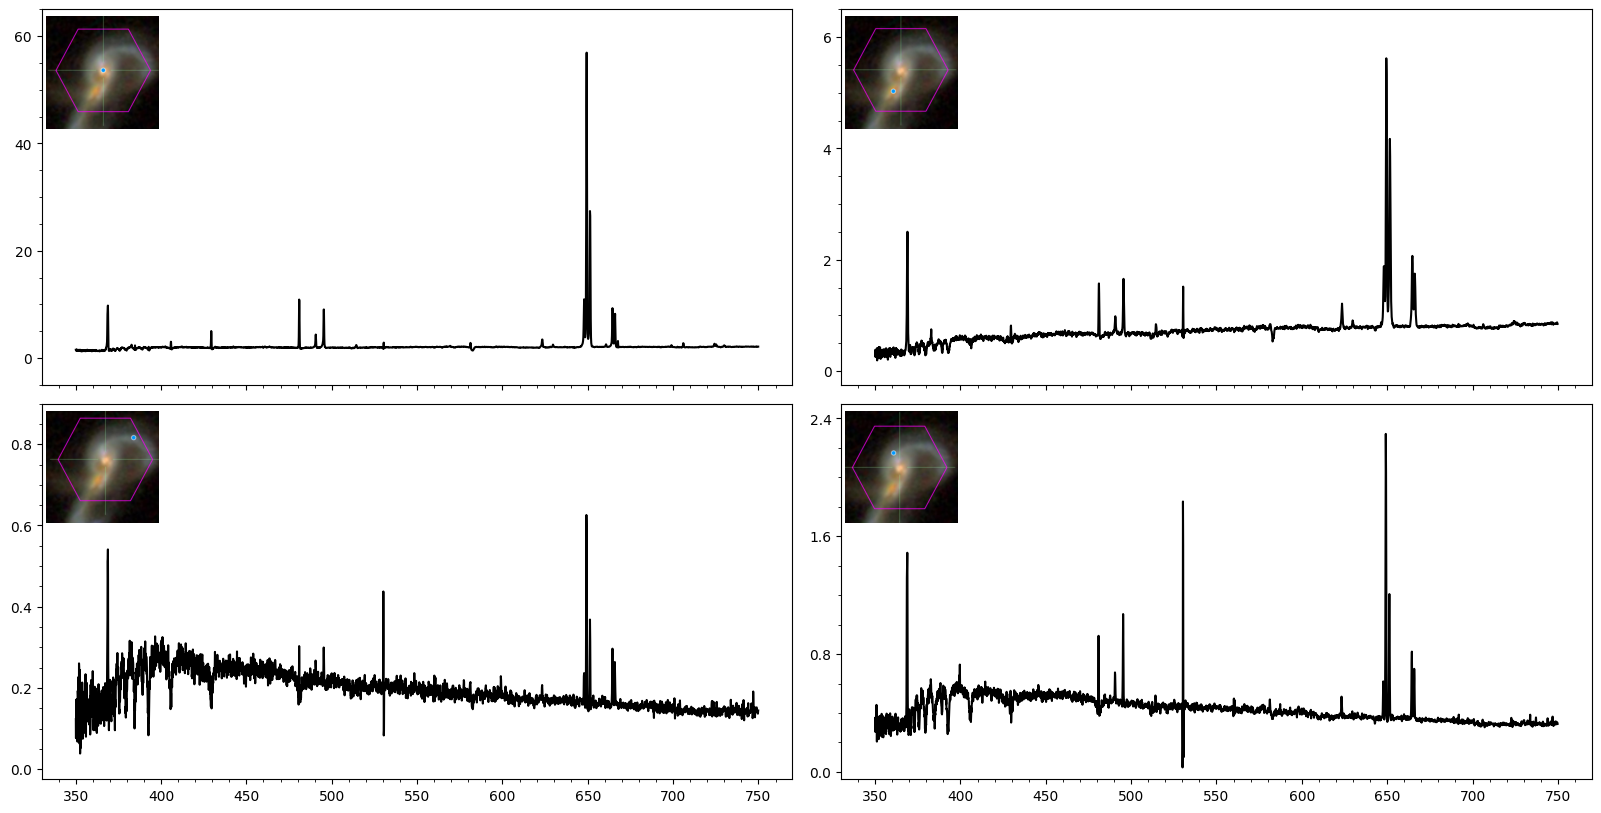

In [7]:
fig, axs = plt.subplots(
    2, 2,
    figsize=(20, 10),
    sharex=True
)
# convert wave to nm 
# -------------------------------------------------------------
# center
axs[0,0].plot(wave_center_rest*0.1, spec_center, color='black')

_ = add_thumbnail(axs[0,0], center_img)

axs[0, 0].set_ylim(-5, 65) 
center_ticks = [0, 20, 40, 60]
axs[0, 0].set_yticks(center_ticks)

# -------------------------------------------------------------
# lower-left
axs[0,1].plot(wave_ll_rest*0.1, spec_ll, color='black')
_ = add_thumbnail(axs[0,1], ll_img)

axs[0, 1].set_ylim(-0.25, 6.5) 
ll_ticks = [0, 2, 4, 6]
axs[0, 1].set_yticks(ll_ticks)

# -------------------------------------------------------------
# upper-right
axs[1,0].plot(wave_ur_rest*0.1, spec_ur, color='black')

_ = add_thumbnail(axs[1,0], ur_img)

axs[1, 0].set_ylim(-0.025, 0.9) 
ur_ticks = [0, 0.2, 0.4, 0.6, 0.8]
axs[1, 0].set_yticks(ur_ticks)
# -------------------------------------------------------------
# upper-left
axs[1,1].plot(wave_ul_rest*0.1, spec_ul, color='black')

_ = add_thumbnail(axs[1,1], ul_img)

axs[1, 1].set_ylim(-0.05, 2.5) 
ul_ticks = [0, 0.8, 1.6, 2.4]
axs[1, 1].set_yticks(ul_ticks)
# 
for ax in axs.flatten(): ax.minorticks_on()
# adjust vertical space
plt.subplots_adjust(
    hspace=0.05,
    wspace=0.065
)

# save figure
fig.savefig(
    f'{ch_3_dir}/fiber_aperture_spectra.pdf',
    bbox_inches='tight'
)